In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully.")
print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)

Libraries imported successfully.
Pandas version: 2.2.3
NumPy version: 2.1.3


In [2]:

import zipfile
import os

zip_path = "/content/archive (7).zip"
extract_path = "/content/adult_income_data"

# Extract the ZIP file
os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("ZIP file extracted successfully!")
print("\nFiles inside the extracted folder:")

for root, dirs, files in os.walk(extract_path):
    for file in files:
        print(os.path.join(root, file))

ZIP file extracted successfully!

Files inside the extracted folder:
/content/adult_income_data/adult.csv


In [4]:
# Load the Adult Income dataset
file_path = "/content/adult_income_data/adult.csv"
df = pd.read_csv(file_path)

# Display basic information
print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

print("\nDataset information:")
df.info()

Dataset loaded successfully!
Dataset shape: (48842, 15)

Column names:
['age', 'workclass', 'fnlwgt', 'education', 'educational-num', 'marital-status', 'occupation', 'relationship', 'race', 'gender', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']

First 5 rows:


,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        48842 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       48842 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12  hours-per-week   48842 non-null  int64 
 13  native-country   48842 non-null  object
 14  income           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


In [5]:

# Cell 4: Initial dataset inspection

print("DATASET OVERVIEW")
print("=" * 50)

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print("Duplicate rows:", df.duplicated().sum())

print("\nCOLUMN DATA TYPES")
print("=" * 50)
display(df.dtypes.to_frame(name="Data Type"))

print("\nMISSING VALUES")
print("=" * 50)

# Count both actual missing values and '?' placeholders
actual_missing = df.isnull().sum()
question_mark_missing = df.select_dtypes(include="object").eq("?").sum()

missing_summary = pd.DataFrame({
    "Actual Missing Values": actual_missing,
    "'?' Placeholders": question_mark_missing.reindex(
        df.columns, fill_value=0
    )
})

display(missing_summary[
    (missing_summary["Actual Missing Values"] > 0) |
    (missing_summary["'?' Placeholders"] > 0)
])

print("\nTARGET DISTRIBUTION")
print("=" * 50)
display(df["income"].value_counts().to_frame(name="Count"))

print("\nTARGET DISTRIBUTION (%)")
display(
    (df["income"].value_counts(normalize=True) * 100)
    .round(2)
    .to_frame(name="Percentage")
)

print("\nNUMERICAL FEATURE SUMMARY")
print("=" * 50)
display(df.describe().T)

DATASET OVERVIEW
Number of rows: 48842
Number of columns: 15
Duplicate rows: 52

COLUMN DATA TYPES


,Data Type
age,int64
workclass,object
fnlwgt,int64
education,object
educational-num,int64
marital-status,object
occupation,object
relationship,object
race,object
gender,object



MISSING VALUES


,Actual Missing Values,'?' Placeholders
workclass,0,2799
occupation,0,2809
native-country,0,857



TARGET DISTRIBUTION


,Count
income,
<=50K,37155
>50K,11687



TARGET DISTRIBUTION (%)


,Percentage
income,
<=50K,76.07
>50K,23.93



NUMERICAL FEATURE SUMMARY


,count,mean,std,min,25%,50%,75%,max
age,48842.0,38.643585,13.710510,17.0,28.0,37.0,48.0,90.0
fnlwgt,48842.0,189664.134597,105604.025423,12285.0,117550.5,178144.5,237642.0,1490400.0
educational-num,48842.0,10.078089,2.570973,1.0,9.0,10.0,12.0,16.0
capital-gain,48842.0,1079.067626,7452.019058,0.0,0.0,0.0,0.0,99999.0
capital-loss,48842.0,87.502314,403.004552,0.0,0.0,0.0,0.0,4356.0
hours-per-week,48842.0,40.422382,12.391444,1.0,40.0,40.0,45.0,99.0


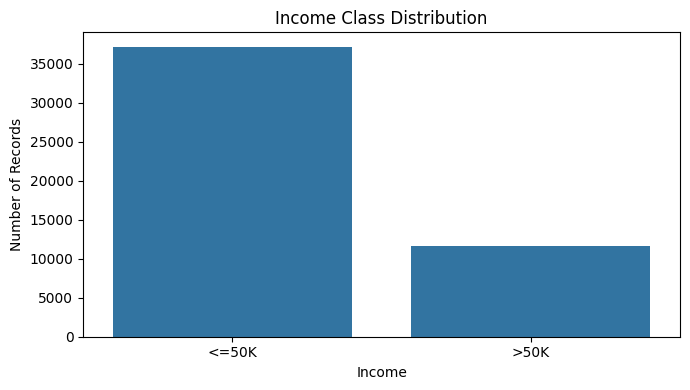

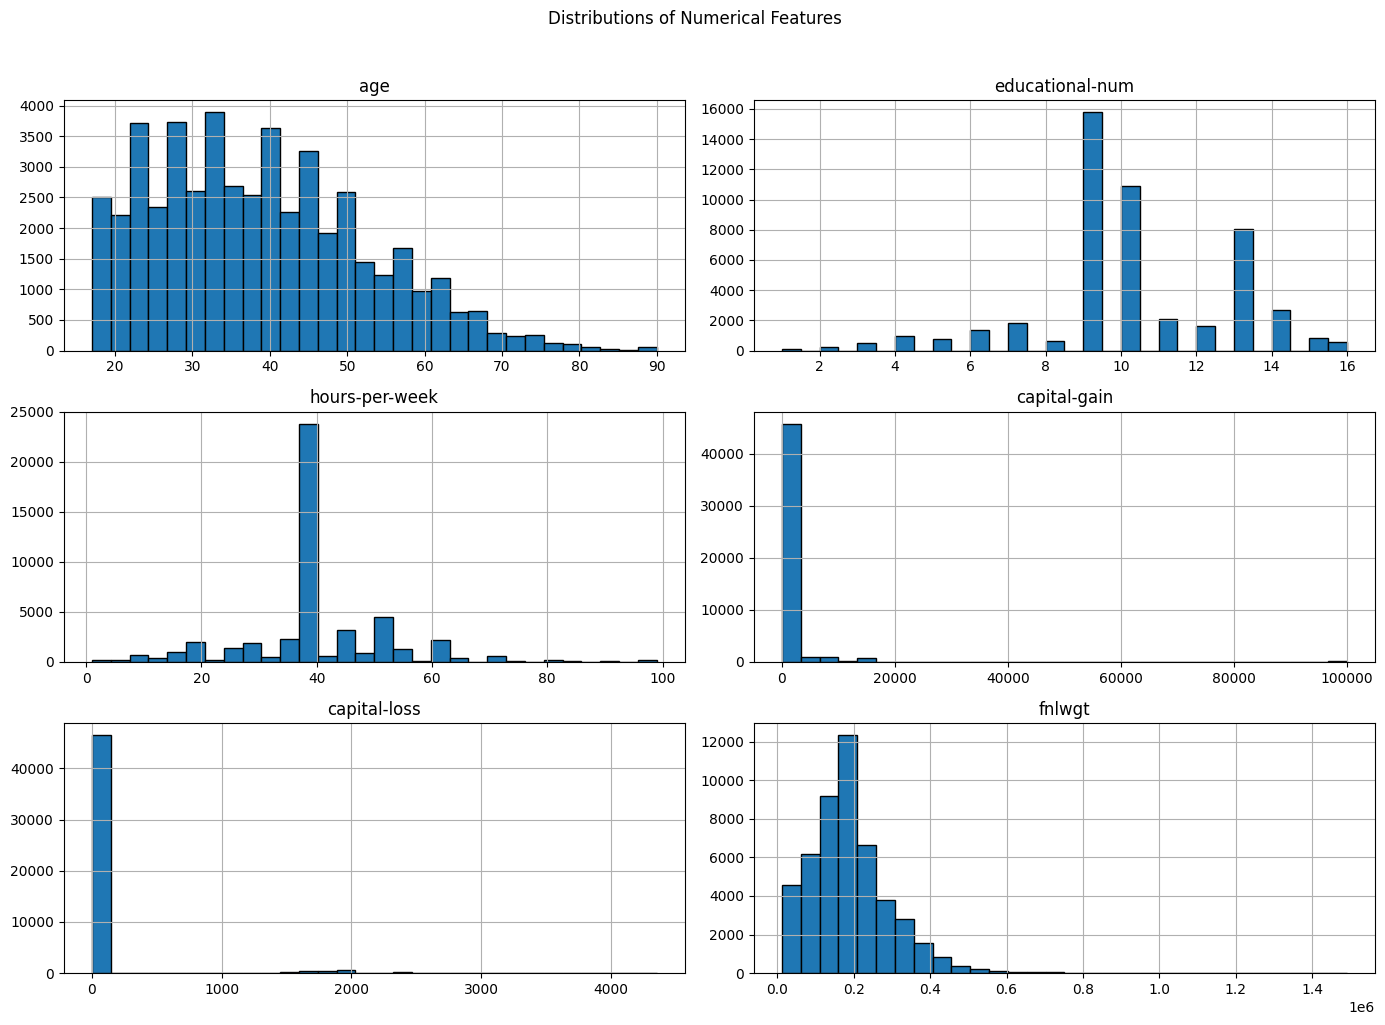

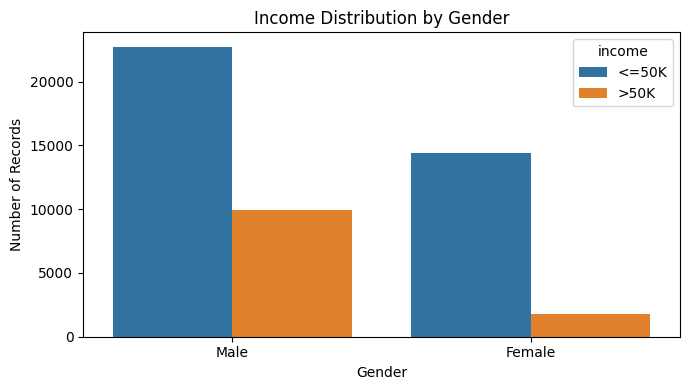

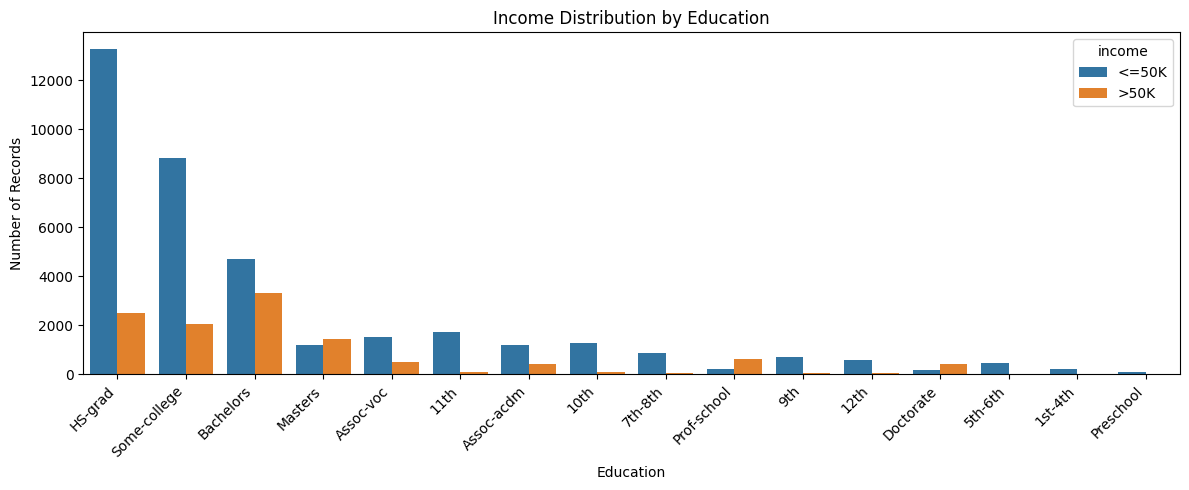

In [6]:

plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="income")
plt.title("Income Class Distribution")
plt.xlabel("Income")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

numerical_columns = [
    "age",
    "educational-num",
    "hours-per-week",
    "capital-gain",
    "capital-loss",
    "fnlwgt"
]

df[numerical_columns].hist(
    figsize=(14, 10),
    bins=30,
    edgecolor="black"
)

plt.suptitle("Distributions of Numerical Features", y=1.02)
plt.tight_layout()
plt.show()


plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="gender", hue="income")
plt.title("Income Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
sns.countplot(
    data=df,
    x="education",
    hue="income",
    order=df["education"].value_counts().index
)
plt.title("Income Distribution by Education")
plt.xlabel("Education")
plt.ylabel("Number of Records")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [7]:

# Cell 6: Data cleaning and feature engineering

# Clean whitespace in categorical columns
categorical_columns = df.select_dtypes(include="object").columns

for col in categorical_columns:
    df[col] = df[col].str.strip()
    df[col] = df[col].replace({"?": np.nan, "": np.nan})

# Remove rows with a missing target
df = df.dropna(subset=["income"]).copy()

# Remove exact duplicate records
duplicates_before = df.duplicated().sum()
df = df.drop_duplicates().copy()

# Feature engineering: indicate whether capital gains/losses are positive
df["has_capital_gain"] = (df["capital-gain"] > 0).astype(int)
df["has_capital_loss"] = (df["capital-loss"] > 0).astype(int)

print("DATA CLEANING SUMMARY")
print("-" * 40)
print("Exact duplicates removed:", duplicates_before)
print("Final dataset shape:", df.shape)
print("Remaining target missing values:", df["income"].isna().sum())

print("\nMissing values by column:")
print(df.isna().sum()[df.isna().sum() > 0])

print("\nIncome distribution after cleaning:")
print(df["income"].value_counts())

print("\nFeature engineering completed.")

DATA CLEANING SUMMARY
----------------------------------------
Exact duplicates removed: 52
Final dataset shape: (48790, 17)
Remaining target missing values: 0

Missing values by column:
workclass         2795
occupation        2805
native-country     856
dtype: int64

Income distribution after cleaning:
income
<=50K    37109
>50K     11681
Name: count, dtype: int64

Feature engineering completed.


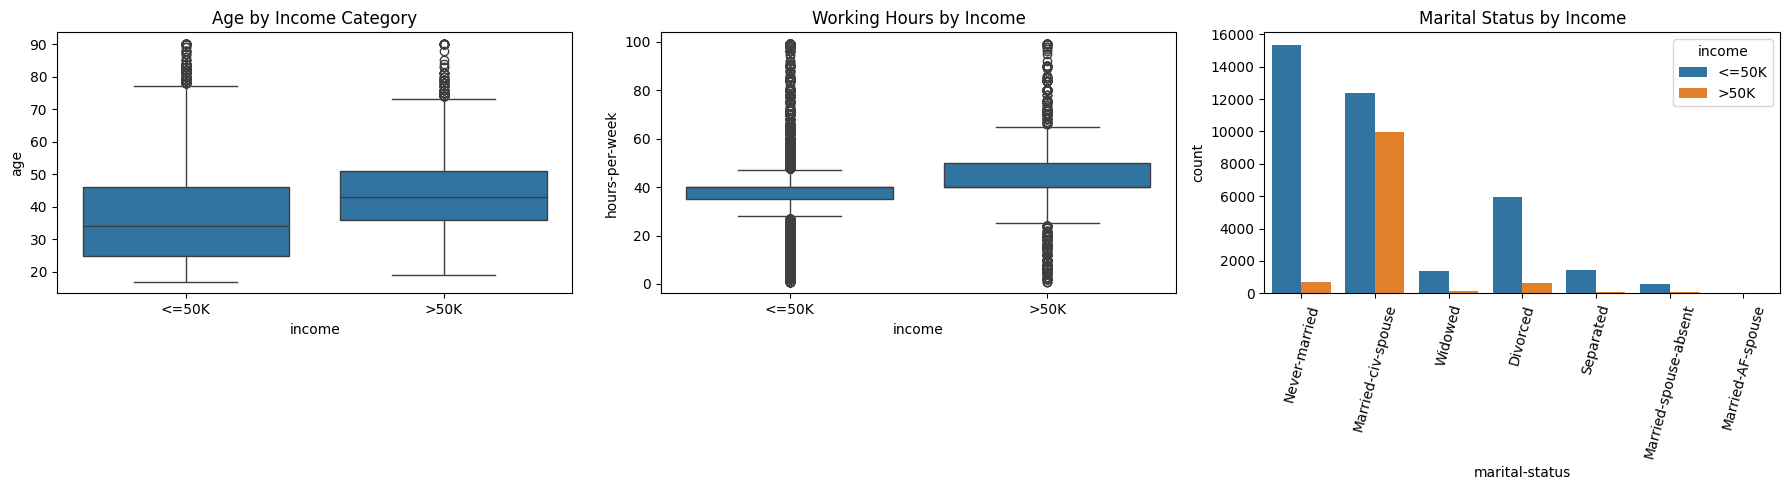

EDA observations to investigate:
- Compare age distributions across income groups.
- Compare working hours across income groups.
- Examine income counts across marital-status categories.
- Remember that associations do not establish causation.


In [8]:

# Cell 7: Additional EDA

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(data=df, x="income", y="age", ax=axes[0])
axes[0].set_title("Age by Income Category")

sns.boxplot(data=df, x="income", y="hours-per-week", ax=axes[1])
axes[1].set_title("Working Hours by Income")

sns.countplot(
    data=df,
    x="marital-status",
    hue="income",
    ax=axes[2]
)
axes[2].set_title("Marital Status by Income")
axes[2].tick_params(axis="x", rotation=75)

plt.tight_layout()
plt.show()

print("EDA observations to investigate:")
print("- Compare age distributions across income groups.")
print("- Compare working hours across income groups.")
print("- Examine income counts across marital-status categories.")
print("- Remember that associations do not establish causation.")

In [9]:

# Cell 8: Split the dataset

from sklearn.model_selection import train_test_split

TARGET = "income"

X = df.drop(columns=[TARGET]).copy()
y = df[TARGET].copy()

# 80% temporary training pool, 20% final test set
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Split the temporary pool into training and validation
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.20,
    random_state=42,
    stratify=y_temp
)

print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)

print("\nTraining proportions:")
print("Train:", round(len(X_train) / len(X) * 100, 2), "%")
print("Validation:", round(len(X_val) / len(X) * 100, 2), "%")
print("Test:", round(len(X_test) / len(X) * 100, 2), "%")

print("\nTarget proportions in each set:")
for name, target_part in [
    ("Train", y_train),
    ("Validation", y_val),
    ("Test", y_test)
]:
    print(f"\n{name}:")
    print((target_part.value_counts(normalize=True) * 100).round(2))

Training set: (31225, 16)
Validation set: (7807, 16)
Test set: (9758, 16)

Training proportions:
Train: 64.0 %
Validation: 16.0 %
Test: 20.0 %

Target proportions in each set:

Train:
income
<=50K    76.06
>50K     23.94
Name: proportion, dtype: float64

Validation:
income
<=50K    76.06
>50K     23.94
Name: proportion, dtype: float64

Test:
income
<=50K    76.06
>50K     23.94
Name: proportion, dtype: float64


In [10]:

# Cell 9: Preprocessing and model training

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Identify feature types
numeric_features = X_train.select_dtypes(
    include=["number"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

# Numerical preprocessing
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical preprocessing
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Combine preprocessing
preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

# Two models to compare
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        solver="liblinear",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=150,
        min_samples_leaf=2,
        class_weight="balanced_subsample",
        n_jobs=-1,
        random_state=42
    )
}

trained_models = {}

for name, classifier in models.items():
    print(f"\nTraining {name}...")

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", classifier)
    ])

    pipeline.fit(X_train, y_train)
    trained_models[name] = pipeline

    print(f"{name} training complete.")

print("\nAll models trained successfully.")


Training Logistic Regression...
Logistic Regression training complete.

Training Random Forest...
Random Forest training complete.

All models trained successfully.


In [11]:

# Cell 10: Validation comparison

def evaluate_model(model, X_data, y_data):
    predictions = model.predict(X_data)

    positive_index = list(model.classes_).index(">50K")
    probabilities = model.predict_proba(X_data)[:, positive_index]

    return {
        "Accuracy": accuracy_score(y_data, predictions),
        "Precision": precision_score(
            y_data, predictions, pos_label=">50K", zero_division=0
        ),
        "Recall": recall_score(
            y_data, predictions, pos_label=">50K", zero_division=0
        ),
        "F1 Score": f1_score(
            y_data, predictions, pos_label=">50K", zero_division=0
        ),
        "ROC-AUC": roc_auc_score(
            (y_data == ">50K").astype(int), probabilities
        )
    }


validation_results = {}

for name, model in trained_models.items():
    validation_results[name] = evaluate_model(
        model, X_val, y_val
    )

# Majority-class baseline for context
from sklearn.dummy import DummyClassifier

baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)

validation_results["Majority Baseline"] = evaluate_model(
    baseline, X_val, y_val
)

validation_table = pd.DataFrame(validation_results).T
display(validation_table.round(4))

# Select using validation F1, not the test set
best_model_name = max(
    trained_models,
    key=lambda name: validation_results[name]["F1 Score"]
)

print("Selected using validation F1:", best_model_name)

,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Logistic Regression,0.8082,0.5667,0.8459,0.6787,0.9088
Random Forest,0.8403,0.6294,0.8095,0.7082,0.9154
Majority Baseline,0.7606,0.0000,0.0000,0.0000,0.5000


Selected using validation F1: Random Forest


SELECTED MODEL: Random Forest

FINAL TEST METRICS


,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Random Forest,0.8323,0.6127,0.8146,0.6994,0.9155



CLASSIFICATION REPORT
              precision    recall  f1-score   support

       <=50K       0.93      0.84      0.88      7422
        >50K       0.61      0.81      0.70      2336

    accuracy                           0.83      9758
   macro avg       0.77      0.83      0.79      9758
weighted avg       0.86      0.83      0.84      9758


CONFUSION MATRIX


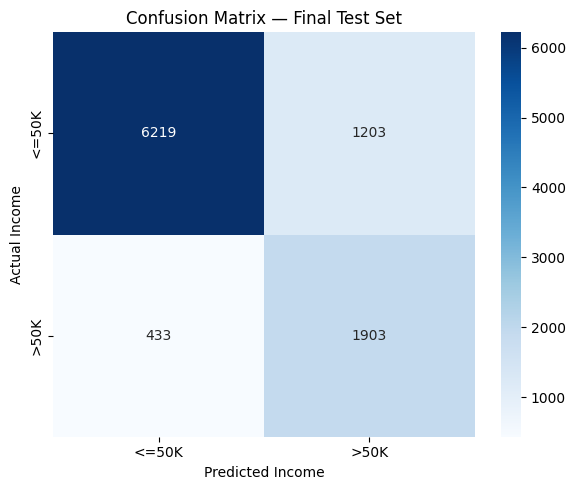

In [12]:

# Cell 11: Final test evaluation

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Combine training and validation data
X_train_val = pd.concat([X_train, X_val], axis=0)
y_train_val = pd.concat([y_train, y_val], axis=0)

# Refit the selected model
best_model = trained_models[best_model_name]
best_model.fit(X_train_val, y_train_val)

# Evaluate once on the held-out test set
test_predictions = best_model.predict(X_test)
test_results = evaluate_model(best_model, X_test, y_test)

print("SELECTED MODEL:", best_model_name)
print("\nFINAL TEST METRICS")
display(pd.DataFrame([test_results], index=[best_model_name]).round(4))

print("\nCLASSIFICATION REPORT")
print(classification_report(
    y_test,
    test_predictions,
    labels=["<=50K", ">50K"],
    zero_division=0
))

print("\nCONFUSION MATRIX")
cm = confusion_matrix(
    y_test,
    test_predictions,
    labels=["<=50K", ">50K"]
)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["<=50K", ">50K"],
    yticklabels=["<=50K", ">50K"]
)
plt.xlabel("Predicted Income")
plt.ylabel("Actual Income")
plt.title("Confusion Matrix — Final Test Set")
plt.tight_layout()
plt.show()

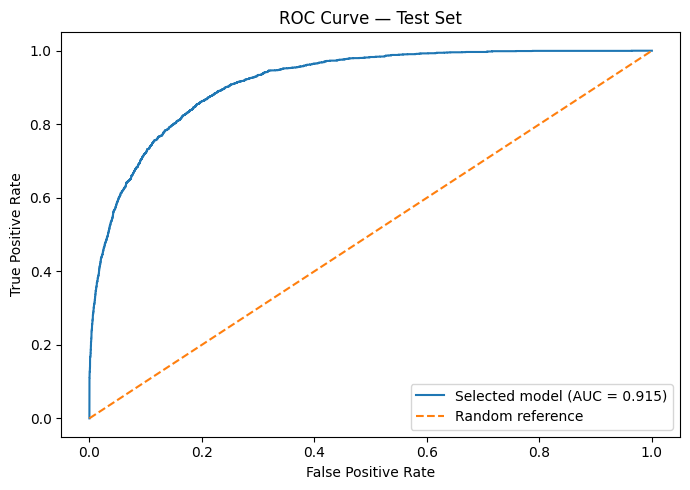

Test ROC-AUC: 0.9155


In [13]:

# Cell 12: ROC curve

from sklearn.metrics import roc_curve, auc

positive_index = list(best_model.classes_).index(">50K")
test_probabilities = best_model.predict_proba(X_test)[:, positive_index]

y_test_binary = (y_test == ">50K").astype(int)

fpr, tpr, thresholds = roc_curve(
    y_test_binary,
    test_probabilities
)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"Selected model (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random reference")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Test Set")
plt.legend()
plt.tight_layout()
plt.show()

print("Test ROC-AUC:", round(roc_auc, 4))

In [14]:

# Cell 13: Save the trained model and results

import os
import joblib

output_dir = "/content/adult_income_outputs"
os.makedirs(output_dir, exist_ok=True)

# Save the full preprocessing + model pipeline
model_path = os.path.join(output_dir, "adult_income_model.joblib")
joblib.dump(best_model, model_path)

# Save evaluation results
validation_table.to_csv(
    os.path.join(output_dir, "validation_comparison.csv")
)

pd.DataFrame(
    [test_results], index=[best_model_name]
).to_csv(
    os.path.join(output_dir, "test_metrics.csv")
)

# Save classification report
report = classification_report(
    y_test,
    test_predictions,
    labels=["<=50K", ">50K"],
    zero_division=0
)

with open(
    os.path.join(output_dir, "classification_report.txt"),
    "w"
) as f:
    f.write(report)

# Save confusion matrix data
pd.DataFrame(
    cm,
    index=["Actual <=50K", "Actual >50K"],
    columns=["Predicted <=50K", "Predicted >50K"]
).to_csv(
    os.path.join(output_dir, "confusion_matrix.csv")
)

print("Artifacts saved in:", output_dir)
print("\nSaved files:")
for filename in sorted(os.listdir(output_dir)):
    print("-", filename)

Artifacts saved in: /content/adult_income_outputs

Saved files:
- adult_income_model.joblib
- classification_report.txt
- confusion_matrix.csv
- test_metrics.csv
- validation_comparison.csv


In [15]:

# Cell 14: Reload and test the saved pipeline

loaded_model = joblib.load(
    "/content/adult_income_outputs/adult_income_model.joblib"
)

# Use one held-out example to verify prediction works
example = X_test.iloc[[0]].copy()

prediction = loaded_model.predict(example)[0]
probabilities = loaded_model.predict_proba(example)[0]
positive_index = list(loaded_model.classes_).index(">50K")

print("Example prediction:", prediction)
print(
    "Probability of income >50K:",
    round(float(probabilities[positive_index]), 4)
)
print("Saved model reload test completed.")

Example prediction: <=50K
Probability of income >50K: 0.0219
Saved model reload test completed.


In [16]:

# Cell 15: Simple interactive prediction prototype

# Create default values using training data only
default_row = X_train_val.mode(dropna=True).iloc[0].to_dict()

def predict_income_from_inputs(
    age,
    education,
    workclass,
    marital_status,
    occupation,
    gender,
    hours_per_week
):
    input_row = default_row.copy()

    input_row["age"] = int(age)
    input_row["education"] = education
    input_row["workclass"] = workclass
    input_row["marital-status"] = marital_status
    input_row["occupation"] = occupation
    input_row["gender"] = gender
    input_row["hours-per-week"] = int(hours_per_week)

    input_df = pd.DataFrame([input_row])[X.columns]

    predicted_income = loaded_model.predict(input_df)[0]
    probabilities = loaded_model.predict_proba(input_df)[0]
    positive_index = list(loaded_model.classes_).index(">50K")

    return predicted_income, float(probabilities[positive_index])


print("ADULT INCOME PREDICTION PROTOTYPE")
print("-" * 40)

age_input = int(input("Age: "))
education_input = input("Education (e.g. Bachelors, HS-grad): ").strip()
workclass_input = input("Workclass (e.g. Private, State-gov): ").strip()
marital_input = input(
    "Marital status (e.g. Never-married, Married-civ-spouse): "
).strip()
occupation_input = input(
    "Occupation (e.g. Sales, Prof-specialty): "
).strip()
gender_input = input("Gender (Male/Female): ").strip()
hours_input = int(input("Hours worked per week: "))

prediction, probability = predict_income_from_inputs(
    age_input,
    education_input,
    workclass_input,
    marital_input,
    occupation_input,
    gender_input,
    hours_input
)

print("\nPrediction:", prediction)
print(f"Estimated model probability of >50K: {probability:.2%}")
print(
    "Note: This is an educational model trained on historical data, "
    "not a reliable assessment of any individual's actual income."
)

ADULT INCOME PREDICTION PROTOTYPE
----------------------------------------
Age: 21
Education (e.g. Bachelors, HS-grad): Bachelors
Workclass (e.g. Private, State-gov): Private
Marital status (e.g. Never-married, Married-civ-spouse): Never-marries
Occupation (e.g. Sales, Prof-specialty): Sales
Gender (Male/Female): Male
Hours worked per week: 40

Prediction: <=50K
Estimated model probability of >50K: 21.59%
Note: This is an educational model trained on historical data, not a reliable assessment of any individual's actual income.


In [17]:

# Cell 16: Generate the project summary

summary = f"""
# Adult Income Classification Project

## 1. Objective
Build a supervised machine learning classifier to predict whether
a person's recorded annual income falls into the >50K or <=50K category.

## 2. Dataset
Source: Kaggle Adult Income Dataset
https://www.kaggle.com/datasets/wenruliu/adult-income-dataset

The dataset contains demographic, employment, education, and
financial-related features. The target column is `income`.

Rows after cleaning: {len(df):,}
Number of input features: {X.shape[1]}

## 3. Data preprocessing
- Standardized whitespace in categorical values.
- Converted '?' placeholders to missing values.
- Removed exact duplicate records.
- Created indicators for positive capital gain and capital loss.
- Imputed missing numerical values using training-set medians.
- Imputed missing categorical values using training-set most frequent values.
- Scaled numerical features.
- One-hot encoded categorical features.

Preprocessing was implemented inside a scikit-learn Pipeline to help
prevent data leakage.

## 4. Experimental setup
- Training: approximately 64% of the cleaned data.
- Validation: approximately 16%.
- Testing: approximately 20%.
- Random seed: 42.
- Stratified splitting preserved the income-class proportions.

Models compared: Logistic Regression and Random Forest.
A majority-class baseline was also evaluated.

## 5. Model selection
Selected model: {best_model_name}
Selection criterion: validation F1-score for the >50K class.

## 6. Final test results
- Accuracy: {test_results['Accuracy']:.4f}
- Precision (>50K): {test_results['Precision']:.4f}
- Recall (>50K): {test_results['Recall']:.4f}
- F1-score (>50K): {test_results['F1 Score']:.4f}
- ROC-AUC: {test_results['ROC-AUC']:.4f}

## 7. Limitations and responsible use
The income labels are historical dataset categories, not verified
current incomes. Missing values, sampling, historical conditions,
and demographic patterns can affect the results. Model predictions
should not be treated as factual judgments about individuals.

## 8. Saved artifacts
- adult_income_model.joblib
- validation_comparison.csv
- test_metrics.csv
- classification_report.txt
- confusion_matrix.csv

## 9. Reproducibility
The notebook contains the loading, EDA, cleaning, preprocessing,
training, validation, evaluation, and prototype steps. Run the cells
in order in Google Colab after providing the dataset file.
"""

summary_path = os.path.join(output_dir, "project_summary.md")

with open(summary_path, "w", encoding="utf-8") as f:
    f.write(summary)

print(summary)
print("\nSummary saved to:", summary_path)


# Adult Income Classification Project

## 1. Objective
Build a supervised machine learning classifier to predict whether
a person's recorded annual income falls into the >50K or <=50K category.

## 2. Dataset
Source: Kaggle Adult Income Dataset
https://www.kaggle.com/datasets/wenruliu/adult-income-dataset

The dataset contains demographic, employment, education, and
financial-related features. The target column is `income`.

Rows after cleaning: 48,790
Number of input features: 16

## 3. Data preprocessing
- Standardized whitespace in categorical values.
- Converted '?' placeholders to missing values.
- Removed exact duplicate records.
- Created indicators for positive capital gain and capital loss.
- Imputed missing numerical values using training-set medians.
- Imputed missing categorical values using training-set most frequent values.
- Scaled numerical features.
- One-hot encoded categorical features.

Preprocessing was implemented inside a scikit-learn Pipeline to help
prevent da

In [18]:

# Cell 17: Create a GitHub README

readme = f"""
# Adult Income Classification

## Project Overview

This project uses supervised machine learning to classify income
records into two categories: `<=50K` and `>50K`.

## Dataset

- Source: [Kaggle Adult Income Dataset](https://www.kaggle.com/datasets/wenruliu/adult-income-dataset)
- Target: `income`
- Features: demographic, education, employment, and financial-related data.

## Workflow

1. Data loading and inspection
2. Exploratory data analysis
3. Missing-value and duplicate handling
4. Feature engineering
5. Stratified train, validation, and test splits
6. Numerical scaling and categorical encoding
7. Logistic Regression and Random Forest experiments
8. Validation-based model selection
9. Final test evaluation
10. Model and report saving
11. Interactive command-line prediction prototype

## Models

Logistic Regression and Random Forest are compared using validation
metrics. A majority-class baseline is included for context.

## Final Test Results

| Metric | Result |
|---|---:|
| Selected model | {best_model_name} |
| Accuracy | {test_results['Accuracy']:.4f} |
| Precision (>50K) | {test_results['Precision']:.4f} |
| Recall (>50K) | {test_results['Recall']:.4f} |
| F1-score (>50K) | {test_results['F1 Score']:.4f} |
| ROC-AUC | {test_results['ROC-AUC']:.4f} |

## Technologies

- Python
- Pandas and NumPy
- Matplotlib and Seaborn
- Scikit-learn
- Joblib
- Google Colab

## Files

- `adult_income_classification.ipynb`: project notebook
- `adult_income_model.joblib`: fitted preprocessing and prediction pipeline
- `validation_comparison.csv`: validation results
- `test_metrics.csv`: final test metrics
- `classification_report.txt`: class-level evaluation
- `confusion_matrix.csv`: confusion matrix values
- `project_summary.md`: project report

## Run the Project

1. Open the notebook in Google Colab.
2. Upload the Adult Income dataset ZIP file.
3. Run the notebook cells in order.
4. Review the validation comparison and final test metrics.
5. Use the command-line prototype to try a sample prediction.

## Limitations and Responsible Use

The model learns from historical data and may reflect biases in the
dataset. Its predictions are educational estimates, not verified
individual income information, and should not be used to make
consequential decisions about people.

## Author

Add your name here.
"""

readme_path = os.path.join(output_dir, "README.md")

with open(readme_path, "w", encoding="utf-8") as f:
    f.write(readme.strip() + "\n")

print("README created:", readme_path)

README created: /content/adult_income_outputs/README.md
